# XGBoost – Multi-Threshold Accessibility Model

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import shap

In [2]:
# # CONFIG
# STATE = "13"
# COUNTIES = ["121", "089", "067", "135"]
# RANDOM_STATE = 42

# # LOAD DATA
# X_df = pd.read_parquet(
#     "../data/processed_predictors/atlanta_2023_predictor_dataset.parquet"
# )

# y_df = pd.read_parquet(
#     "../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet"
# )

# print(X_df.shape, y_df.shape)

In [3]:
# CONFIG
STATE = "08"
COUNTIES = ["031"]
RANDOM_STATE = 42

# LOAD DATA
X_df = pd.read_parquet(
    "../data/processed_predictors/denver_2024_predictor_dataset.parquet"
)

y_df = pd.read_parquet(
    "../data/processed_job_accessibility/accessibility_state-CO_counties-031_year-2023_thresholds-15-30-45-60.parquet"
)

print(X_df.shape, y_df.shape)

(178, 44) (178, 5)


In [4]:
# DEFINE MULTI-THRESHOLD TARGETS
target_cols = [
    "jobs_15min",
    "jobs_30min",
    "jobs_45min",
    "jobs_60min"
]

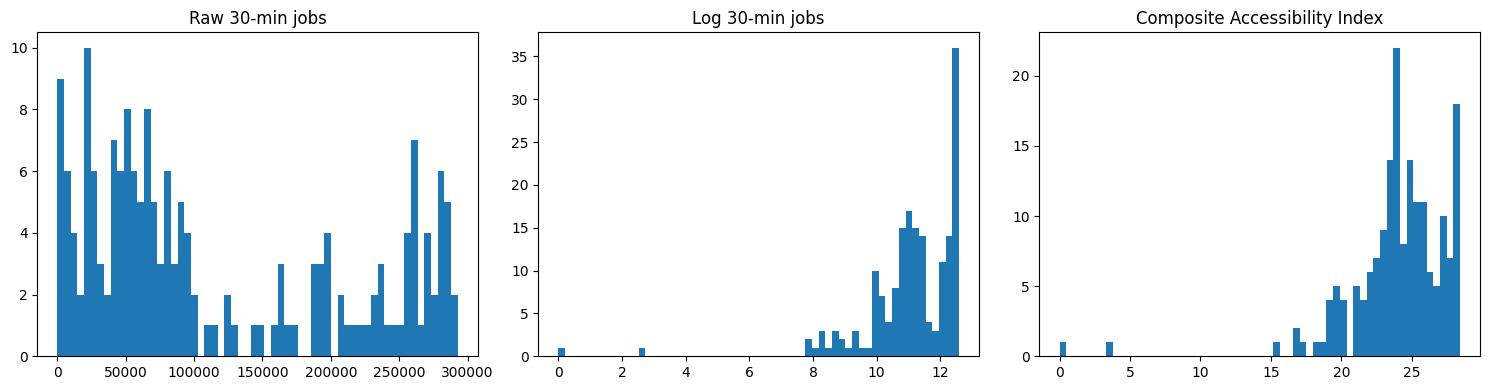

In [5]:
# COMPOSITE ACCESSIBILITY INDEX (MAIN TARGET)

weights = np.array([1.0, 0.7, 0.4, 0.2])

y_multi = np.log1p(y_df[target_cols])

y_df["access_index"] = (y_multi * weights).sum(axis=1)

# %%
# TARGET DISTRIBUTION CHECK
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(y_df["jobs_30min"], bins=60)
axes[0].set_title("Raw 30-min jobs")

axes[1].hist(np.log1p(y_df["jobs_30min"]), bins=60)
axes[1].set_title("Log 30-min jobs")

axes[2].hist(y_df["access_index"], bins=60)
axes[2].set_title("Composite Accessibility Index")

plt.tight_layout()
plt.show()

In [6]:
# MERGE MAIN DATASET
df = X_df.merge(
    y_df[["from_id"] + target_cols + ["access_index"]],
    left_on="tract_id",
    right_on="from_id",
    how="inner"
)

print(df.shape)

(178, 50)


In [7]:
# LOAD GEOMETRY
url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)
tracts = tracts[tracts["COUNTYFP"].isin(COUNTIES)].copy()
tracts["tract_id"] = tracts["GEOID"].astype(str)

In [8]:
# MERGE GEOMETRY
df = df.merge(
    tracts[["tract_id", "geometry"]],
    on="tract_id",
    how="left"
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=tracts.crs)

In [9]:
# PROJECT
gdf = gdf.to_crs(epsg=5070).copy()

# %%
# CENTROIDS
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

In [10]:
# FEATURES
drop_cols = [
    "tract_id",
    "from_id",
    "geometry",
    "centroid",
    "x",
    "y"
] + target_cols + ["access_index"]

feature_cols = [c for c in gdf.columns if c not in drop_cols]

X = gdf[feature_cols]

# CLEAN
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# PRIMARY TARGET
y = gdf["access_index"]

print("Features:", len(feature_cols))

Features: 43


In [11]:
# TRAIN / TEST SPLIT
train_idx, test_idx = train_test_split(
    gdf.index,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_mask = gdf.index.isin(train_idx)
test_mask = gdf.index.isin(test_idx)

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

In [12]:
# MODEL
model = XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_lambda=10,
    objective="reg:squarederror",
    random_state=RANDOM_STATE
)

In [13]:
# TRAIN
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [14]:
# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [15]:
# PREDICT
y_pred = model.predict(X_test)

In [16]:
# METRICS (on composite index)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.0712078433753658
RMSE: 1.359634827564725
R2: 0.7208854448674309


In [17]:
# RESULTS
pd.DataFrame([{"mae": mae, "rmse": rmse, "r2": r2}])

,mae,rmse,r2
0,1.071208,1.359635,0.720885


In [18]:
# PREDICTIONS
predictions_df = pd.DataFrame({
    "tract_id": gdf.loc[test_mask, "tract_id"],
    "actual": y_test,
    "predicted": y_pred
})

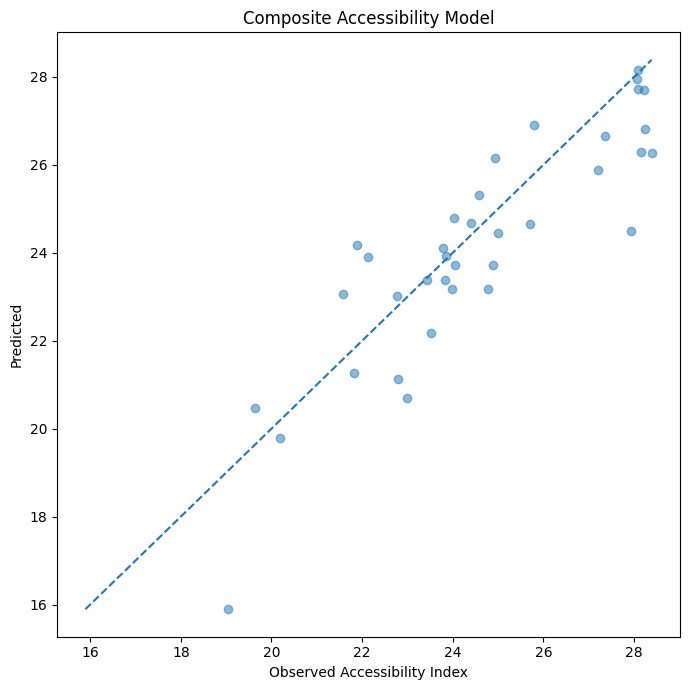

In [19]:
# SCATTER
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(predictions_df["actual"], predictions_df["predicted"], alpha=0.5)

min_val = min(predictions_df["actual"].min(), predictions_df["predicted"].min())
max_val = max(predictions_df["actual"].max(), predictions_df["predicted"].max())

ax.plot([min_val, max_val], [min_val, max_val], "--")

ax.set_xlabel("Observed Accessibility Index")
ax.set_ylabel("Predicted")
ax.set_title("Composite Accessibility Model")

plt.tight_layout()
plt.show()

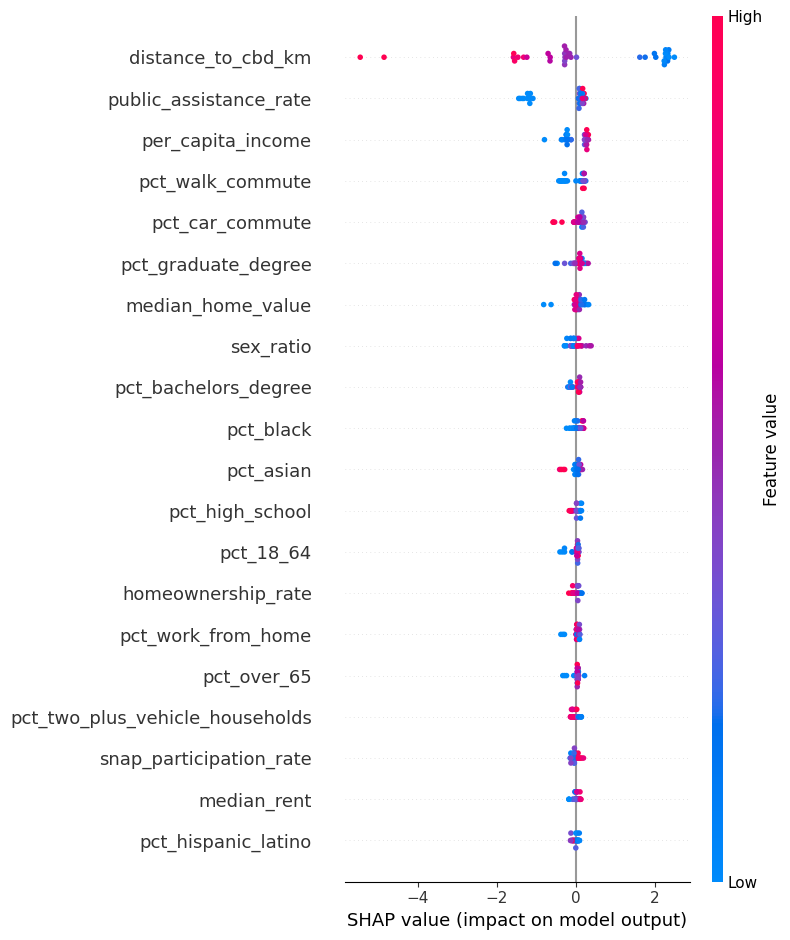

In [20]:
# SHAP SUMMARY
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.show()

In [21]:
# FEATURE IMPORTANCE
shap_importance = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(20)

,feature,mean_abs_shap
37,distance_to_cbd_km,1.496246
15,public_assistance_rate,0.448454
10,per_capita_income,0.268032
25,pct_walk_commute,0.227128
24,pct_car_commute,0.169989
18,pct_graduate_degree,0.143576
33,median_home_value,0.121974
5,sex_ratio,0.118165
17,pct_bachelors_degree,0.100661
39,pct_black,0.095664
